In [27]:
import cv2
import numpy as np
import random
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from pathlib import Path


In [28]:
IMG_SIZE = 128

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel, padding=kernel//2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        ]
        if pool:
            layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)
    def forward(self, x):
        return self.block(x)

class MetalCNN(nn.Module):
    def __init__(self, in_ch=1, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(in_ch, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256, pool=True)
        )
        final_spatial = IMG_SIZE // (2**4)
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(256 * final_spatial * final_spatial, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


In [29]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MetalCNN().to(device)
model_path = Path("artifact/models/best_model.pth")
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print("Model loaded successfully!")


Model loaded successfully!


In [30]:
def generate_cluttered_scene(img_size=128):
    H, W = img_size, img_size
    
    # 1. Background
    background = np.random.randint(0, 40, (H, W)).astype(np.uint8)
    background = cv2.GaussianBlur(background, (9, 9), 0)

    # 2. Add random clutter
    clutter = background.copy()
    for _ in range(random.randint(4, 9)):
        shape_type = random.choice(["rect", "circle"])
        
        if shape_type == "rect":
            x1, y1 = random.randint(0, W-15), random.randint(0, H-15)
            x2, y2 = x1 + random.randint(8, 20), y1 + random.randint(8, 20)
            col = random.randint(50,120)
            cv2.rectangle(clutter, (x1, y1), (x2, y2), col, -1)

        else:
            cx, cy = random.randint(0, W), random.randint(0, H)
            r = random.randint(5, 15)
            col = random.randint(50,120)
            cv2.circle(clutter, (cx, cy), r, col, -1)

    # 3. Hidden metal object (Gaussian blob)
    cx, cy = random.randint(10, 54), random.randint(10, 54)
    sigma = random.uniform(3, 7)

    xs, ys = np.arange(W), np.arange(H)
    X, Y = np.meshgrid(xs, ys)
    obj = np.exp(-((X - cx)**2 + (Y - cy)**2) / (2*sigma*sigma))
    obj = (obj * 255).astype(np.uint8)

    # 4. Blend metal BEHIND clutter
    alpha = random.uniform(0.3, 0.8)
    final = np.maximum(clutter, (obj * alpha).astype(np.uint8))

    return background, obj, final


In [31]:
def clean_image(img):
    img_blur = cv2.GaussianBlur(img, (5, 5), 0)
    img_med  = cv2.medianBlur(img_blur, 3)
    return img_med

def background_subtract(bg, frame):
    diff = cv2.absdiff(bg, frame)
    _, mask = cv2.threshold(diff, 15, 255, cv2.THRESH_BINARY)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,
                            np.ones((3,3), np.uint8))
    return mask

def preprocess_scene(bg, cluttered_scene):
    cleaned = clean_image(cluttered_scene)
    mask = background_subtract(bg, cleaned)
    masked_frame = cv2.bitwise_and(cleaned, cleaned, mask=mask)
    return masked_frame


In [32]:
def evaluate_on_clutter(model, device, num_samples=200):
    correct = 0

    for _ in range(num_samples):
        bg, obj_img, final = generate_cluttered_scene()

        processed = preprocess_scene(bg, final)

        x = torch.tensor(processed/255.0, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        output = model(x)
        pred = output.argmax(dim=1).item()

        # In this test, metal is ALWAYS present
        label = 1  

        if pred == label:
            correct += 1

    acc = correct / num_samples
    print(f"Cluttered Hidden-Metal Detection Accuracy: {acc:.3f}")
    return acc


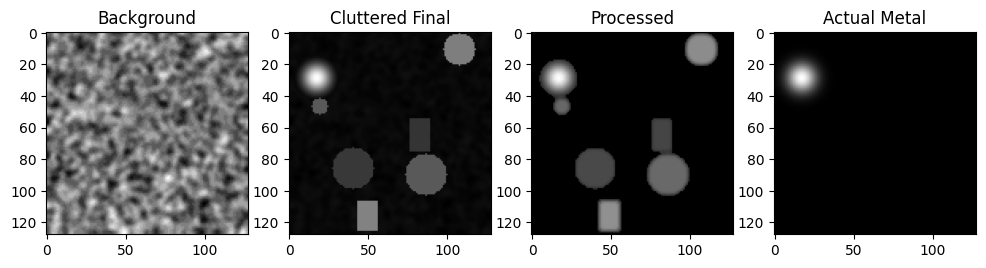

In [33]:
bg, obj_img, final = generate_cluttered_scene()
processed = preprocess_scene(bg, final)

plt.figure(figsize=(12,3))
plt.subplot(1,4,1); plt.imshow(bg, cmap='gray'); plt.title("Background")
plt.subplot(1,4,2); plt.imshow(final, cmap='gray'); plt.title("Cluttered Final")
plt.subplot(1,4,3); plt.imshow(processed, cmap='gray'); plt.title("Processed")
plt.subplot(1,4,4); plt.imshow(obj_img, cmap='gray'); plt.title("Actual Metal")
plt.show()


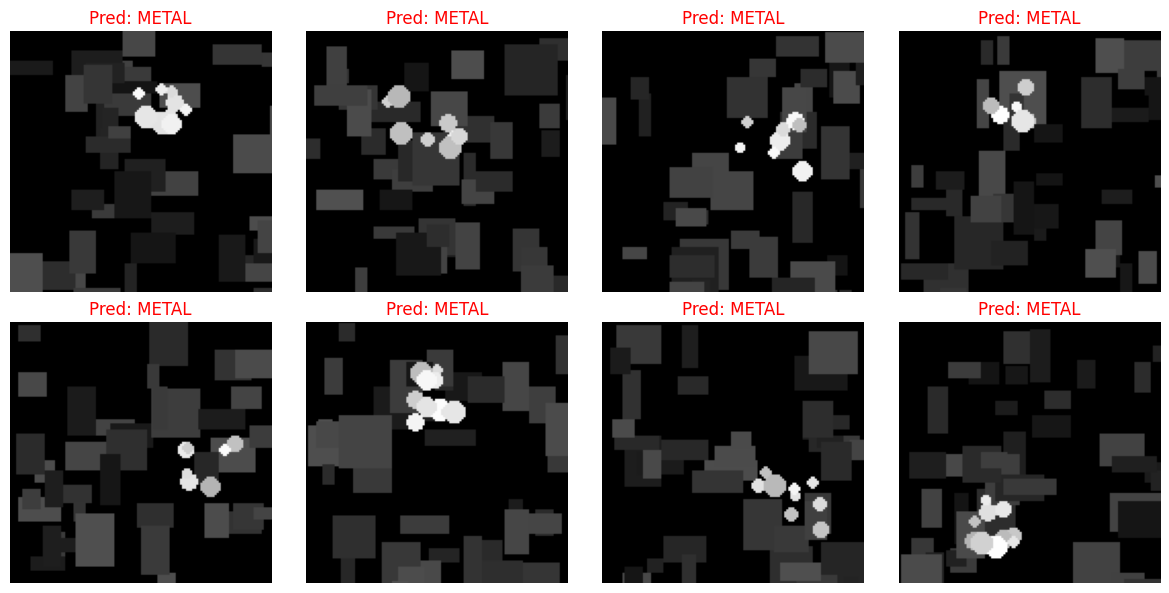

In [35]:
import matplotlib.pyplot as plt

def visualize_predictions_grid(model, transform, rows=2, cols=4):
    fig, axs = plt.subplots(rows, cols, figsize=(12, 6))

    for i in range(rows * cols):
        img, pred = predict_on_generated_scene(model, transform)

        ax = axs[i // cols][i % cols]
        ax.imshow(img, cmap="gray")
        ax.set_title(f"Pred: {'METAL' if pred == 1 else 'NO-METAL'}", color="red" if pred else "green")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

visualize_predictions_grid(model, transform)


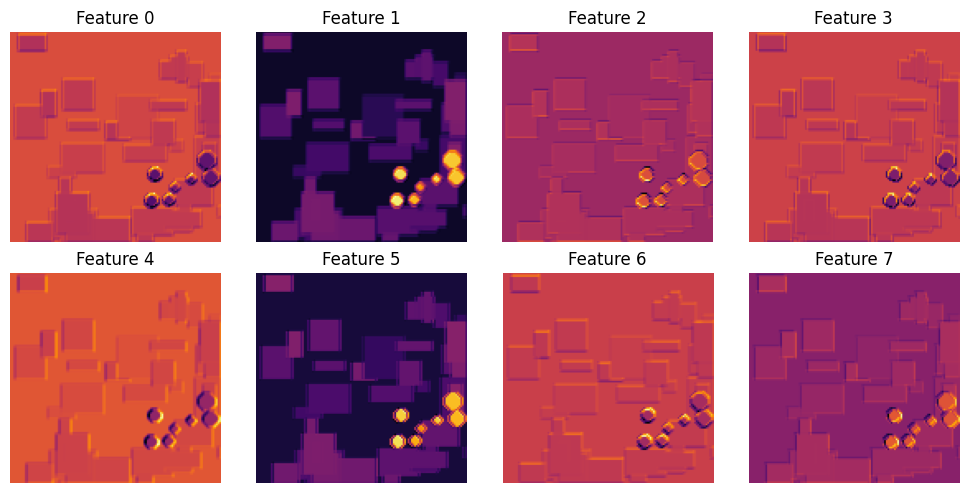

In [36]:
import torch.nn.functional as F

def show_feature_maps(model, transform):
    # 1. Generate image
    img = generate_clutter_scene(IMG_SIZE)
    x = transform(img).unsqueeze(0).to(device)

    # 2. Forward only first conv layer
    first_layer = model.features[0].block[0]  # Conv2D
    with torch.no_grad():
        features = first_layer(x)

    features = features.squeeze().cpu().numpy()

    # 3. Show first 8 feature maps
    fig, axs = plt.subplots(2, 4, figsize=(10, 5))

    for i in range(8):
        ax = axs[i // 4][i % 4]
        ax.imshow(features[i], cmap="inferno")
        ax.set_title(f"Feature {i}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_feature_maps(model, transform)


Cluttered Hidden-Metal Detection Accuracy: 1.000


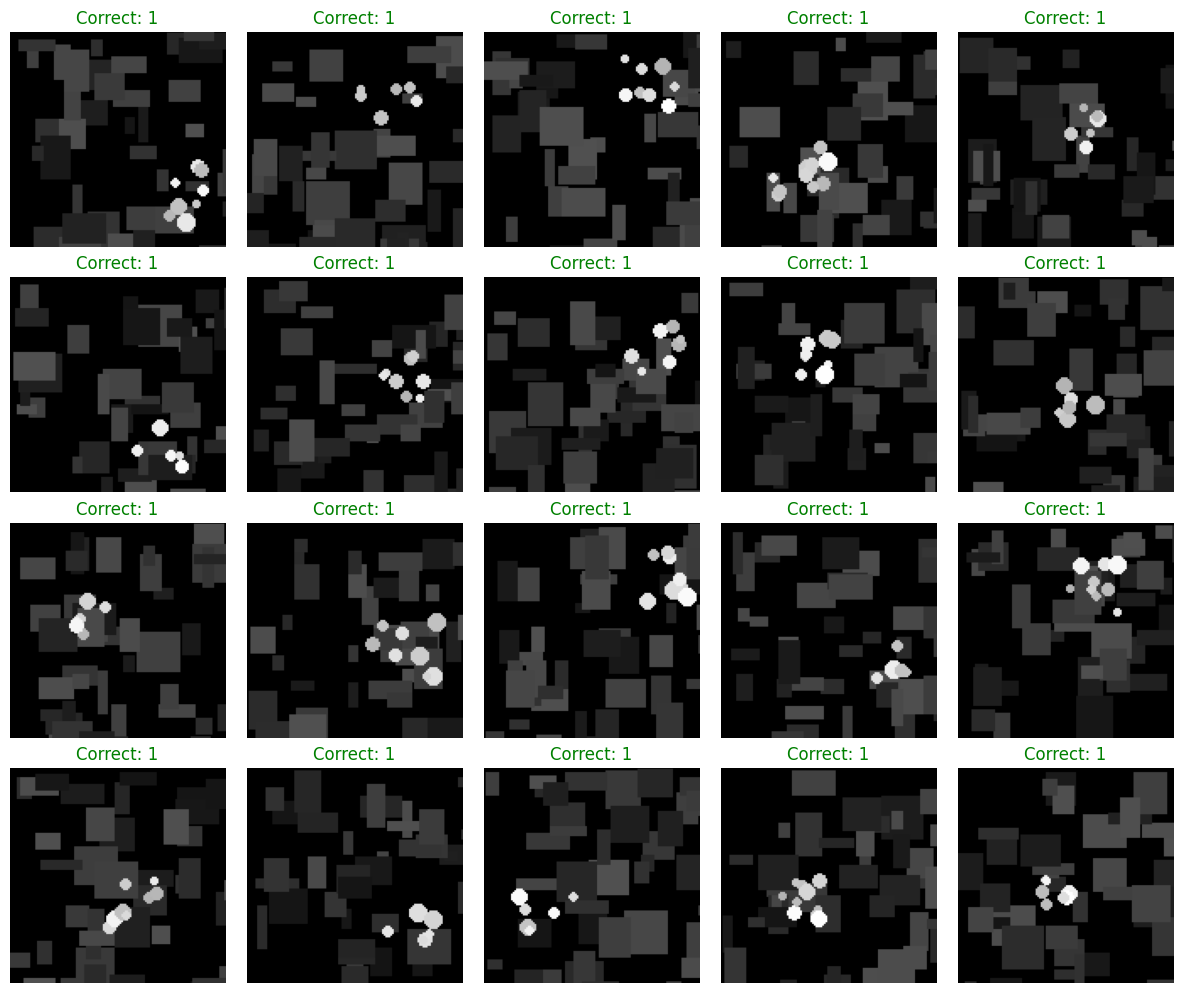

In [42]:
def visualize_correct_classifications(model, transform, n=20):
    correct_cases = []

    while len(correct_cases) < n:
        img, pred = predict_on_generated_scene(model, transform)
        true_label = 1  # in synthetic data, metal is ALWAYS present

        if pred == true_label:
            correct_cases.append((img, pred))

    fig, axs = plt.subplots(4, 5, figsize=(12, 10))

    for idx, (img, pred) in enumerate(correct_cases):
        ax = axs[idx // 5][idx % 5]
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Correct: {pred}", color="green")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Run it:
evaluate_on_clutter(model, device, num_samples=300)

visualize_correct_classifications(model, transform, n=20)
